In [24]:
!pip install pandas

In [25]:
!pip install matplotlib

In [26]:
!pip install seaborn

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("employe.csv")


In [29]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


Verifying the presence of duplicate records in the dataset.

In [30]:
print(df.duplicated().sum())

3008


**Upon executing the command, I identified 3,008 duplicate rows in the dataset. Consequently, I proceeded to remove these duplicate records to improve data quality and ensure accurate analysis.**

In [31]:
df = df.drop_duplicates()

In [32]:
print(df.shape[0]) #i have used .shape[0] as it returns the number of rows

11991


Removed duplicate records from the dataset.

After removing the duplicate values, the dataset contains **11,991 unique employees**. The **drop_duplicates** operation was applied to ensure that each employee was counted only once, thereby preventing redundancy in the analysis.

Additionally, I standardized the column names by **removing special characters and spaces** to facilitate accurate and readable visualizations using **Matplotlib and Seaborn**.

In [33]:
df = df.rename(columns={
    'satisfactoryLevel': 'satisfactory_level',
    'lastEvaluation': 'last__evaluation',
    'numberOfProjects': 'number__of__projects',
    'avgMonthlyHours': 'avg__monthly__hours',
    'timeSpent.company': 'time__spent__company',
    'workAccident': 'work__accident',
    'promotionInLast5years': 'last__5years__promotion',
    'dept': 'department'
})

In [34]:
print( df.columns.tolist())

['satisfactory_level', 'last__evaluation', 'number__of__projects', 'avg__monthly__hours', 'time__spent__company', 'work__accident', 'left', 'last__5years__promotion', 'department', 'salary']


I checked the dataset for missing values and removed them, as their presence could lead to errors or inaccuracies in the analysis.

In [35]:
missing = df.isnull().sum()


In [36]:
print("Missing values in each column:")
print(missing)

Missing values in each column:
satisfactory_level         0
last__evaluation           0
number__of__projects       0
avg__monthly__hours        0
time__spent__company       0
work__accident             0
left                       0
last__5years__promotion    0
department                 0
salary                     0
dtype: int64


After performing the necessary data cleaning operations, all columns now show **0 missing values**, indicating that the **dataset is clean and ready for analysis**.


As part of the analysis, I **verified** the **current workforce** count and **identified employees who have left the organization**, to gain an accurate understanding of workforce dynamics.

I assigned a value of **0** to the left column for employees who are currently **employed** and a value of **1** for those who have **exited** the organization.

In [37]:
workforce_employed = df[df['left'] == 0].shape[0]
workforce_left = df[df['left'] == 1].shape[0]
print("workforce_employed: ")
print(workforce_employed)
print("workforce_left:")
print(workforce_left)

workforce_employed: 
10000
workforce_left:
1991


From the dataset, I observed that **10,000 employee**s are currently **employed**, while **1,991 employees** have **left** the organization.

I will visualize this information using a **bar chart** generated with Matplotlib and Seaborn to provide a clear representation of workforce status.

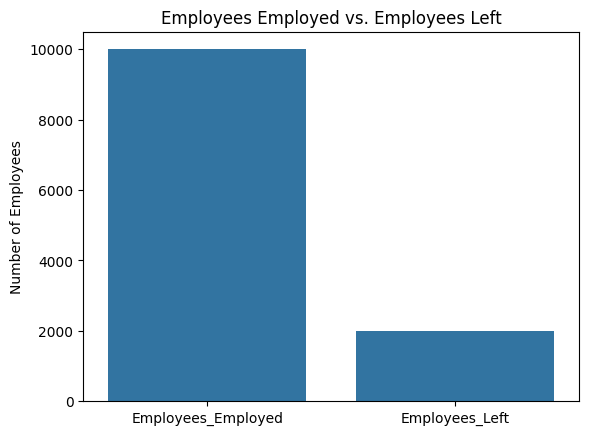

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.title('Employees Employed vs. Employees Left')
counts = df['left'].value_counts().rename(index={0: 'Employees_Employed', 1: 'Employees_Left'}) #['left'] is the column name in our dataset.
sns.barplot(x=counts.index, y=counts.values)
plt.xlabel('') #i had left blank as it's no use of write anything in x axis.
plt.ylabel('Number of Employees')
plt.show()

I analyzed the dataset to identify the departments experiencing the highest attrition rates.

For assessing **department-wise attrition**, I computed the **proportion** of employees who **exited the organization** as a **percentage** of the **total employees in each department**.

In [39]:
total_department = df['department'].value_counts()
department_left = df[df['left'] == 1]['department'].value_counts() #left==1 as 1 ensures the employees had left company from each department
department_attrition = (department_left / total_department * 100).sort_values(ascending=False)
print(department_attrition)




department
hr             18.801997
accounting     17.552335
technical      17.379679
support        17.133443
sales          16.980550
marketing      16.641902
IT             16.188525
product_mng    16.034985
RandD          12.247839
management     11.926606
Name: count, dtype: float64


Using a **DataFrame**, I will summarize each department by showing the total employee count, the number of departures, and the calculated attrition rate.

#**In case of an error in the next cell, ensure that the preceding cell has been executed, as it provides the necessary data or variables.**

In [40]:
department_attrition = pd.DataFrame({
    'Total': total_department,
    'Left': department_left,
    'Attrition Rate': department_attrition
}).fillna(0)
print(department_attrition)

             Total  Left  Attrition Rate
department                              
IT             976   158       16.188525
RandD          694    85       12.247839
accounting     621   109       17.552335
hr             601   113       18.801997
management     436    52       11.926606
marketing      673   112       16.641902
product_mng    686   110       16.034985
sales         3239   550       16.980550
support       1821   312       17.133443
technical     2244   390       17.379679


I am visualizing the attrition rates across departments using a **bar plot**.

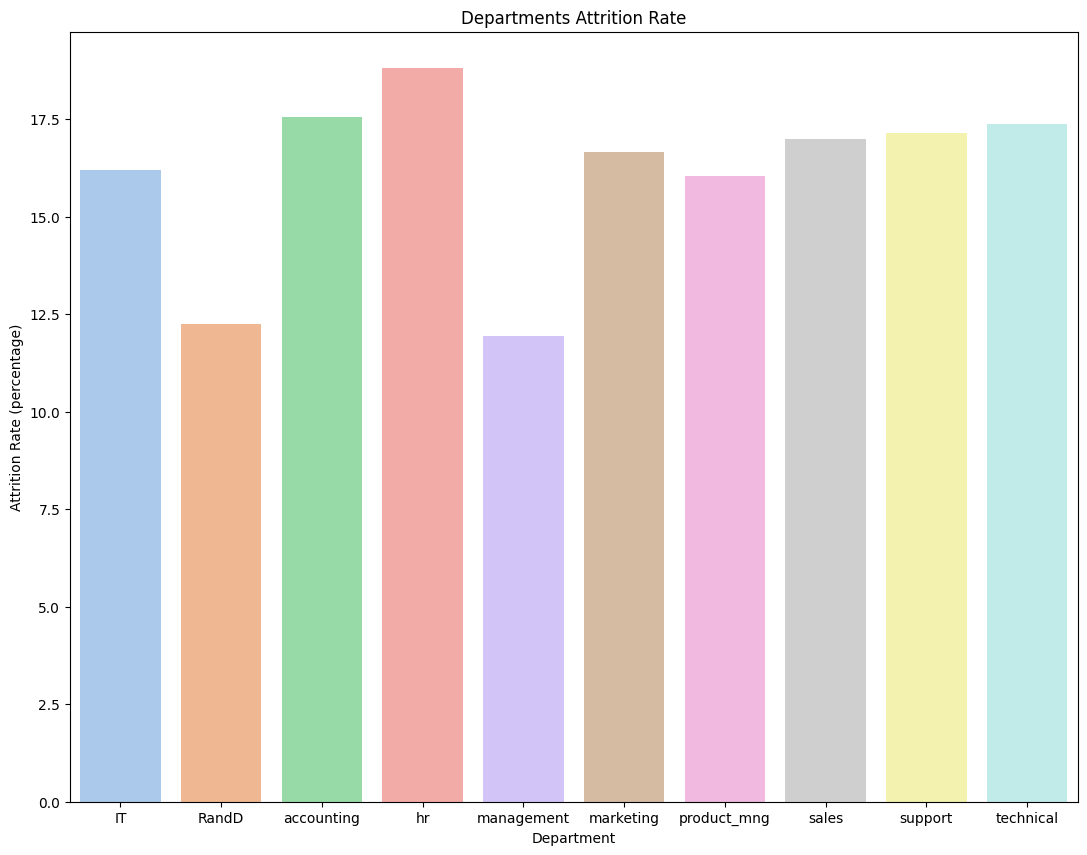

In [41]:
plt.figure(figsize=(13,10))
sns.barplot(x=department_attrition.index, y='Attrition Rate', data=department_attrition, palette='pastel')
plt.title('Departments Attrition Rate')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (percentage)')
plt.show()


#A FutureWarning appeared due to the absence of a hue parameter. To address this, I applied the filterwarnings command to suppress the warning.

import warnings
warnings.filterwarnings('ignore')

I analyzed the data to determine that employees working on **fewer than three projects** are more likely to **leave** the company.

As part of the **data organization** process, I categorized employees into **two distinct groups** based on their project assignments: employees involved in **fewer than three projects** and employees involved in **more than three projects**. Accordingly, I created a directory named “**less Project Employees**” to systematically store and manage records of employees working on fewer than three projects.

In [42]:
df['less_project_employees'] = df['number__of__projects'] < 3

project_groups = df.groupby('less_project_employees')['left'].agg(['count', 'sum']) # i am using group by function and calculating count and number of employees who left.
project_groups['Attrition Rate(percent)'] = (project_groups['sum'] / project_groups['count']) * 100   #i am finding attrition rate for both the groups.
project_groups = project_groups.round(2) #i am using ".round(2)" function to round off my output to only 2 decimal for the ease of calculation & understanding.
print(project_groups)


                        count   sum  Attrition Rate(percent)
less_project_employees                                      
False                   10409  1134                    10.89
True                     1582   857                    54.17


In this context, **False** represents employees assigned to **three or more** projects, while **True** represents employees assigned to **fewer than three projects**. The observation indicates that employees handling **fewer than three** projects exhibit a **higher attrition rate** compared to those assigned to three or more projects.

To illustrate this trend, I visualized the data using a **bar plot** generated with Matplotlib.

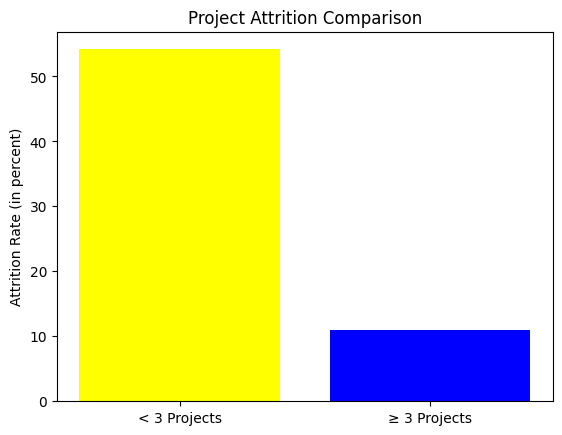

In [43]:
#I calculated the number of employees who were assigned fewer than three projects and have left the company, as well as those still employed with fewer than three projects.
#I then performed the same calculation for employees assigned three or more projects, identifying both those who have exited and those who are currently employed.
#The shape function of Pandas was used to obtain the total row count in each category.


less_projects = df[(df['number__of__projects'] < 3) & (df['left'] == 1)].shape[0]

total_less_projects = df[df['number__of__projects'] < 3].shape[0]

more_projects = df[(df['number__of__projects'] >= 3) & (df['left'] == 1)].shape[0]

total_more_projects = df[df['number__of__projects'] >= 3].shape[0]

#I am preparing a bar chart, which requires calculating the attrition rates for employees assigned fewer than three projects and those assigned three or more projects.
attrition_less_projects = less_projects / total_less_projects * 100
attrition_more_projects = more_projects / total_more_projects * 100

x = ['< 3 Projects', '≥ 3 Projects']
y = [attrition_less_projects, attrition_more_projects]

plt.bar(x, y, color=['yellow', 'blue'])
plt.title('Project Attrition Comparison')
plt.ylabel('Attrition Rate (in percent)')
plt.show()



The analysis indicates that employees assigned to **fewer than three projects** exhibit significantly **higher attrition rates** compared to those assigned to three or more projects.

I am analyzing whether the **number of projects correlates with the tenure at the company**, with a particular focus on **employees who have left** the organization.

I am analyzing and evaluating the data from two columns in the dataset: **number_of_projects** and **time_spent_company**. As required, I have created a **separate column** to indicate **employees who have left** the organization.

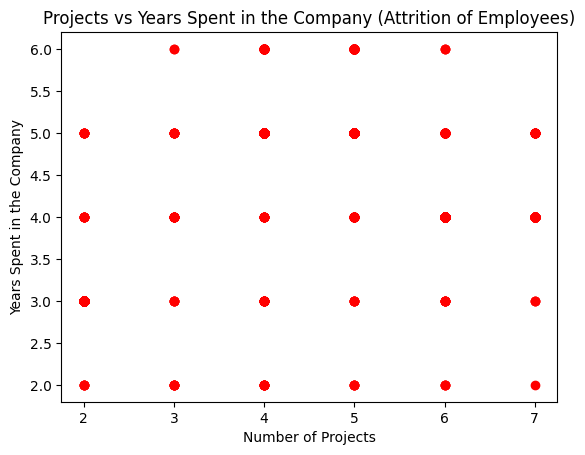

In [44]:
# Scatter plot
left_df = df[df['left'] == 1]

plt.scatter(left_df['number__of__projects'], left_df['time__spent__company'], color='red')
plt.title('Projects vs Years Spent in the Company (Attrition of Employees)')
plt.xlabel('Number of Projects')
plt.ylabel('Years Spent in the Company')
plt.show()


I am analyzing whether **compensation levels** influence an **employee’s decision to leave** the organization.

The salary column is categorized into **low, medium, and high**, while the left column indicates employee status, with **1** representing employees who have **left** and **0** representing those who are **still employed**.

I first segmented the employees into **three salary groups** and then calculated the **attrition rate** for each group, comparing employees with high salaries to those with low salaries.

In [45]:
# I utilized the groupby and aggregate functions to organize the data and compute summary statistics for each salary group.
salary_of_group = df.groupby('salary')['left'].agg(['sum', 'count'])
salary_of_group['Rate Of Attrition (in percent)'] = (salary_of_group['sum'] / salary_of_group['count'] * 100).round(2) #i am using .round function to round off my output to only 2 decimals.
salary_of_group


,sum,count,Rate Of Attrition (in percent)
salary,,,
high,48,990,4.85
low,1174,5740,20.45
medium,769,5261,14.62


Text(0, 0.5, 'Attrition Rate (in percent)')

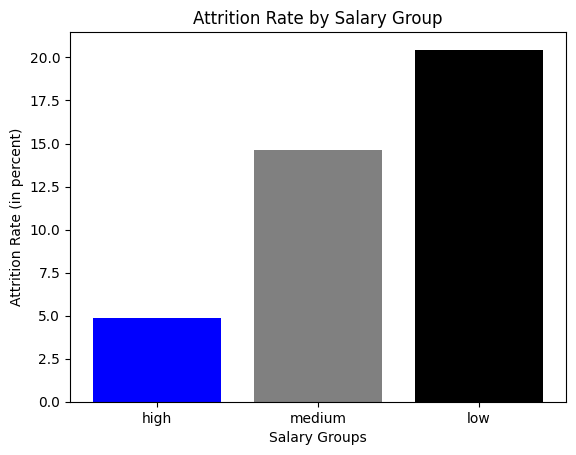

In [46]:
labels = ['high', 'medium', 'low']
Attrition_Rates = [salary_of_group.loc['high', 'Rate Of Attrition (in percent)'],
         salary_of_group.loc['medium', 'Rate Of Attrition (in percent)'],
         salary_of_group.loc['low', 'Rate Of Attrition (in percent)']]


plt.bar(labels,Attrition_Rates, color=['blue', 'grey', 'black'])
plt.title('Attrition Rate by Salary Group')
plt.xlabel('Salary Groups')
plt.ylabel('Attrition Rate (in percent)')

The visualization and analysis indicate that employees with **low salaries** exhibit a significantly **higher attrition rate** compared to employees with high salaries.

Employees in the **high-salary category** have an attrition rate of approximately **5%**, whereas employees in the **low-salary category** show an attrition rate of over **20%**.

This suggests that employees with **lower compensation** are more likely to **leave the organization** than those with higher salaries.

Therefore, **competitive compensation** can play a **crucial** role in employee **retention**.

Providing employees with **higher salaries** can be an **effective strategy to reduce attrition**.

#**Insights Derived from the Data Analysis:**
#The following observations were made while analyzing the dataset:



*   The dataset originally comprised **14,999 employee**s. Following the **removal** of **3,008 duplicate** entries during **data cleaning**, the dataset now contains **11,991 distinct employee** records.
*   While analyzing the data, it was found that employees in the **Accounting and HR departments** experience the **highest levels of attrition**, in contrast to the **R&D and Management departments**, which show the **lowest attrition rates**.

*   It was observed that **employees** handling **less than three** projects are more likely to **leave the organization** than employees managing three or more projects.
* It was observed that **experienced employees** who **exited** the organization generally **handled more projects** compared to others.


* **Low-salary employees** showed an attrition rate of around **20%**, compared to **5%** for **high-salary employees**, suggesting that **increasing compensation** can help **improve employee retention**.







#While analyzing the dataset, it was identified that HR can adopt the following measures to minimize attrition:


* Provide competitive salaries or performance incentives to employees in the low-salary bracket to improve motivation and reduce attrition.
*  Since employees handling fewer projects exhibit higher attrition rates, assigning them additional responsibilities may help improve their engagement and retention.


* Departments with high attrition can benefit from career pathing, recognition programs, and targeted retention efforts to reduce employee turnover.
*   Experienced employees with high project loads can be retained more effectively through recognition, career pathing, and development opportunities.



